# Reward & Community Energy Analysis

Plots produced:
1. **Training episode return** — mean ± min/max band over training iterations.
2. **Mean reward by hour** — grouped bar chart, one bar per agent per hour.
3. **Overall mean reward per agent** — single bar chart collapsed over all hours.
4. **Community energy metrics by hour** — overlapping bar chart (generation, demand, P2P, import, export).
5. **All-pairs interaction grid** — tiny line plots for every ordered pair (i→j): traded power + bid/ask quantities and clearing price + bid/ask prices.

## Configuration

In [4]:
import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

In [5]:
def plot_rewards_comparison(exp_names, algorithm="PPO",
                            base_root="/home/juanbmedina/rllib/exp_results",
                            labels=None, figsize=(8, 4.5)):
    """Plot episode_return_mean curves from multiple runs on the same axes.

    Parameters
    ----------
    exp_names : list[str]
        Folder names under base_root to load (one per run).
    algorithm : str
        Algorithm subdirectory name (default "PPO").
    base_root : str
        Root directory where experiment folders live.
    labels : list[str] or None
        Legend labels. If None, uses exp_names.
    figsize : tuple
        Figure size.
    """
    if labels is None:
        labels = exp_names
    assert len(labels) == len(exp_names), "labels must match exp_names length"

    fig, ax = plt.subplots(figsize=figsize)

    for exp_name, label in zip(exp_names, labels):
        path = (f"{base_root}/{exp_name}/energy_market_training/"
                f"{algorithm}_energy_market_run/progress.csv")
        df = pd.read_csv(path)
        x = df["training_iteration"] if "training_iteration" in df.columns else df.index + 1
        ax.plot(x, df["env_runners/episode_return_mean"],
                label=label, linewidth=1.6, alpha=0.9)

    ax.set_xlabel("Training iteration")
    ax.set_ylabel("Episode return (mean)")
    ax.set_title(f"Reward comparison across {len(exp_names)} runs")
    ax.legend(loc="best", fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, ax

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_rewards_comparison_multiseed_ind(
    paths,
    seeds=None,
    labels=None,
    title="Reward comparison across runs",
    figsize=(8, 4.5),
    ylim=(0, 9000),
    highlight_seeds=None,    # None -> todas iguales; lista -> resalta solo esas
    highlight_colors=None,   # opcional: lista de colores paralela a highlight_seeds
    muted_color="lightgray",
):
    """Plot episode_return_mean curves from multiple runs on the same axes.

    Parameters
    ----------
    paths : list[str]
        Paths to progress.csv files (one per run).
    seeds : list[int] | None
        Seed values used as legend labels. If None, extracted from each path
        via the regex `seed(\\d+)`.
    labels : list[str] | None
        Optional override of legend labels. Takes precedence over `seeds`.
    highlight_seeds : list[int] | None
        If None (default), every curve is drawn with equal styling.
        If a list of seed numbers is given, ONLY those curves are drawn
        bold + colored, and every other curve is muted in gray.
    highlight_colors : list[str] | None
        Optional list of colors aligned with `highlight_seeds`. If None,
        falls back to matplotlib's default tab cycle.
    """

    fig, ax = plt.subplots(figsize=figsize)

    # ---------- resolve seed for each run ----------
    resolved_seeds = []
    for i, path in enumerate(paths):
        if seeds is not None:
            resolved_seeds.append(int(seeds[i]))
        else:
            m = re.search(r"seed(\d+)", path)
            resolved_seeds.append(int(m.group(1)) if m else i)

    # ---------- resolve label for each run ----------
    resolved_labels = []
    for i, s in enumerate(resolved_seeds):
        if labels is not None:
            resolved_labels.append(labels[i])
        else:
            resolved_labels.append(f"Seed {s}")

    # ---------- load data ----------
    runs = []
    for path, seed, label in zip(paths, resolved_seeds, resolved_labels):
        df = pd.read_csv(path)
        x = df["training_iteration"] if "training_iteration" in df.columns else df.index + 1
        y = df["env_runners/episode_return_mean"]
        runs.append({"x": x, "y": y, "seed": seed, "label": label})

    # ---------- plotting branches ----------
    if not highlight_seeds:
        # Default mode: plot everything with the default color cycle.
        for r in runs:
            ax.plot(r["x"], r["y"], label=r["label"],
                    linewidth=2.5, alpha=0.9)
    else:
        highlight_set = set(int(s) for s in highlight_seeds)

        # Map each highlighted seed to a color
        if highlight_colors is None:
            cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
            color_map = {s: cycle[i % len(cycle)] for i, s in enumerate(highlight_seeds)}
        else:
            color_map = {int(s): c for s, c in zip(highlight_seeds, highlight_colors)}

        # Draw muted curves first so highlighted sit on top
        muted_seen = False
        for r in runs:
            if r["seed"] in highlight_set:
                continue
            ax.plot(r["x"], r["y"],
                    color=muted_color, linewidth=2.2, alpha=1.0, zorder=1,
                    label=None if muted_seen else "other seeds")
            muted_seen = True

        # Draw highlighted curves on top, in the order given by highlight_seeds
        # (so legend order matches the user's intent).
        seed_to_run = {r["seed"]: r for r in runs}
        for s in highlight_seeds:
            s = int(s)
            if s not in seed_to_run:
                print(f"[plot] warning: seed {s} not found among loaded runs.")
                continue
            r = seed_to_run[s]
            ax.plot(r["x"], r["y"], label=r["label"],
                    color=color_map[s], linewidth=3.5, alpha=1.0, zorder=10)

    ax.set_xlabel("Training iteration")
    ax.set_ylabel("Episode return (mean)")
    ax.set_title(title)
    ax.set_ylim(ylim)
    ax.legend(loc="best", fontsize=11, frameon=False)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, ax

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_rewards_comparison_multiseed(
    experiments,
    iter_col="training_iteration",
    mean_col="env_runners/episode_return_mean",
    min_col="env_runners/episode_return_min",
    max_col="env_runners/episode_return_max",
    seed_aggregation="mean",       # "mean" or "envelope"
    figsize=(8, 4.5),
    title="Reward comparison across runs",
    xlabel="Training iteration",
    ylabel="Episode return",
    colors=None,
    linewidth=2.0,
    band_alpha=0.20,
    show_individual=False,
    individual_alpha=0.15,
    ax=None,
):
    """Multi-seed RL learning curves: mean line + min/max shaded band.

    For every iteration:
      - center line = mean of episode_return_mean across seeds
      - band  [low, high] = (mean or envelope) of episode_return_min/max
                            across seeds

    `seed_aggregation`:
      "mean"     -> per-iteration min/max are averaged across seeds.
                    Typical episode spread within an iteration.
      "envelope" -> min-of-mins / max-of-maxes across seeds. Absolute
                    worst/best episode envelope observed in any seed.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    if colors is None:
        cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        colors = [cycle[i % len(cycle)] for i in range(len(experiments))]

    for (label, paths), color in zip(experiments.items(), colors):
        # ---- 1) load all seeds, build wide DataFrames -------------------
        means_per_seed, mins_per_seed, maxs_per_seed = {}, {}, {}
        for k, p in enumerate(paths):
            df = pd.read_csv(p)
            idx = (df[iter_col].astype(int).values
                   if iter_col in df.columns else np.arange(1, len(df) + 1))
            means_per_seed[f"seed_{k}"] = pd.Series(df[mean_col].values, index=idx)
            mins_per_seed[f"seed_{k}"]  = pd.Series(df[min_col].values,  index=idx)
            maxs_per_seed[f"seed_{k}"]  = pd.Series(df[max_col].values,  index=idx)

        means_wide = pd.DataFrame(means_per_seed).sort_index()
        mins_wide  = pd.DataFrame(mins_per_seed).sort_index()
        maxs_wide  = pd.DataFrame(maxs_per_seed).sort_index()

        # ---- 2) aggregate across seeds ----------------------------------
        mid = means_wide.mean(axis=1, skipna=True)
        if seed_aggregation == "mean":
            lower = mins_wide.mean(axis=1, skipna=True)
            upper = maxs_wide.mean(axis=1, skipna=True)
        elif seed_aggregation == "envelope":
            lower = mins_wide.min(axis=1, skipna=True)
            upper = maxs_wide.max(axis=1, skipna=True)
        else:
            raise ValueError("seed_aggregation must be 'mean' or 'envelope'")

        x = mid.index.values

        # ---- 3) optional faint individual seed traces -------------------
        if show_individual:
            for col in means_wide.columns:
                ax.plot(means_wide.index.values, means_wide[col].values,
                        color=color, alpha=individual_alpha,
                        linewidth=1, zorder=1)

        # ---- 4) shaded min/max band -------------------------------------
        ax.fill_between(
            x, lower.values, upper.values,
            color=color, alpha=band_alpha, linewidth=0, zorder=2,
        )

        # ---- 5) mean line on top ----------------------------------------
        ax.plot(x, mid.values,
                color=color, linewidth=linewidth, label=label, zorder=3)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="best", fontsize=11, frameon=False)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0)

    fig.tight_layout()
    return fig, ax

{'Scenario 1 ISGT': ['/home/juanbmedina/rllib/exp_results_repro/scenario1_v2_ISGT/energy_market_training_seed42_run1/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/scenario1_v2_ISGT/energy_market_training_seed43_run2/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/scenario1_v2_ISGT/energy_market_training_seed44_run3/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/scenario1_v2_ISGT/energy_market_training_seed45_run4/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/scenario1_v2_ISGT/energy_market_training_seed46_run5/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/scenario1_v2_ISGT/energy_market_training_seed47_run6/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/scenario1_v2_ISGT/energy_market_training_seed48_run7/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/scena

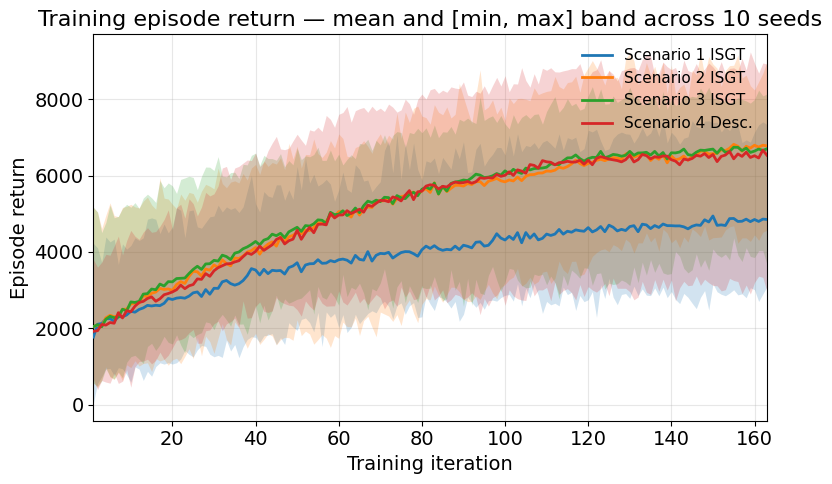

In [8]:
base_root = "/home/juanbmedina/rllib/exp_results_repro"
seeds = np.arange(42, 52)

def collect_paths(exp_name, seeds):
    return [
        f"{base_root}/{exp_name}/energy_market_training_seed{s}_run{i+1}"
        f"/PPO_energy_market_run/progress.csv"
        for i, s in enumerate(seeds)
    ]

experiments = {
    "Scenario 1 ISGT":  collect_paths("scenario1_v2_ISGT", seeds),
    "Scenario 2 ISGT":     collect_paths("scenario2_v2_ISGT", seeds),
    "Scenario 3 ISGT": collect_paths("scenario3_v2_ISGT", seeds),
    "Scenario 4 Desc.": collect_paths("descentralized_exp", seeds),
}
print(experiments)

fig, ax = plot_rewards_comparison_multiseed(
    experiments,
    seed_aggregation="envelope",     # o "envelope"
    figsize=(8, 5),
    title="Training episode return — mean and [min, max] band across 10 seeds",
)
plt.show()

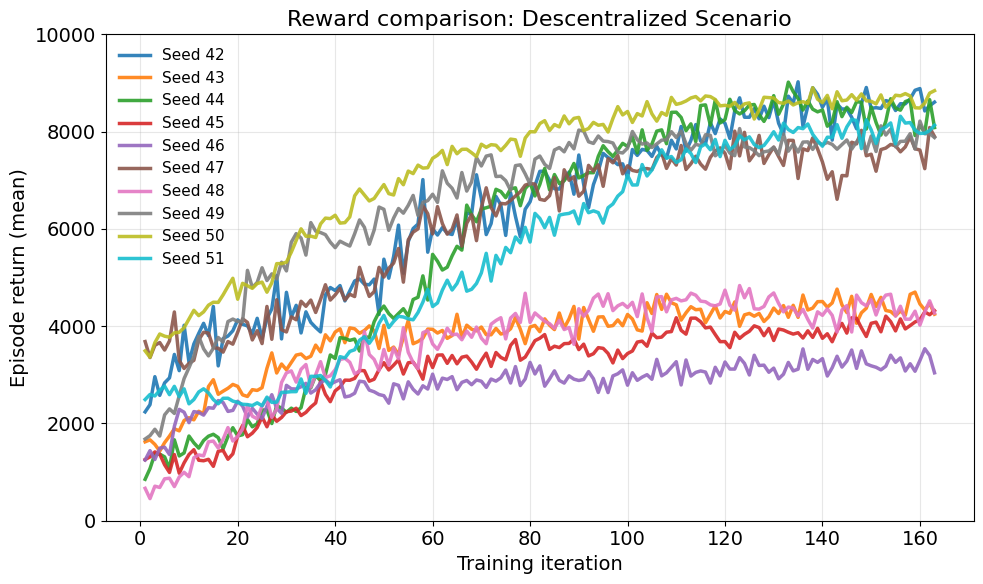

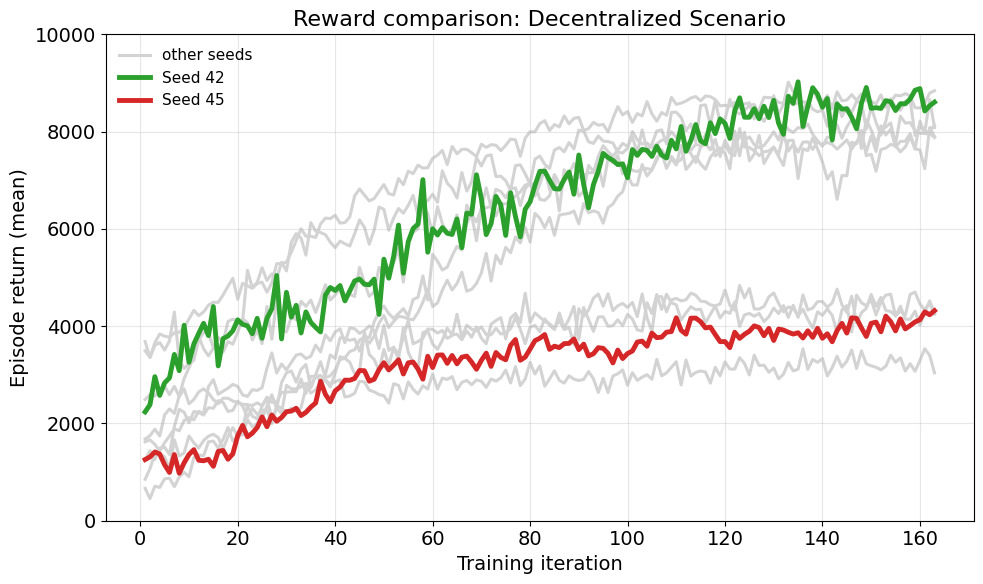

In [9]:
exp_name = 'descentralized_exp'
seeds = np.arange(42,52,1)
paths = []
labels = []
for i, seed in enumerate(seeds):
    path = f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed{seed}_run{i+1}/PPO_energy_market_run/progress.csv'
    paths.append(path)
    labels.append(f'Seed {seed}')
# paths = [
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run1/PPO_energy_market_run/progress.csv',
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run2/PPO_energy_market_run/progress.csv',
#     # f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run3/PPO_energy_market_run/progress.csv'
# ]
fig, ax = plot_rewards_comparison_multiseed_ind(
    paths,
    labels=labels,
    title="Reward comparison: Descentralized Scenario",
    figsize=(10, 6),
    ylim=[0,10000]
)
plt.show()

fig, ax = plot_rewards_comparison_multiseed_ind(
    paths, seeds=seeds,
    title="Reward comparison: Decentralized Scenario",
    figsize=(10, 6), ylim=(0, 10000),
    highlight_seeds=[42, 45],
    highlight_colors=["tab:green", "tab:red"],
)
plt.show()

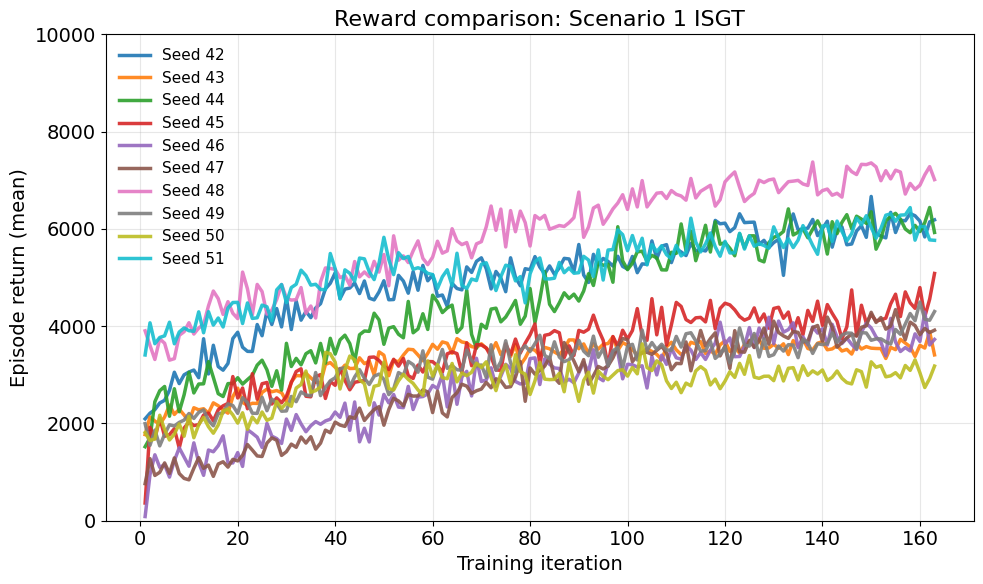

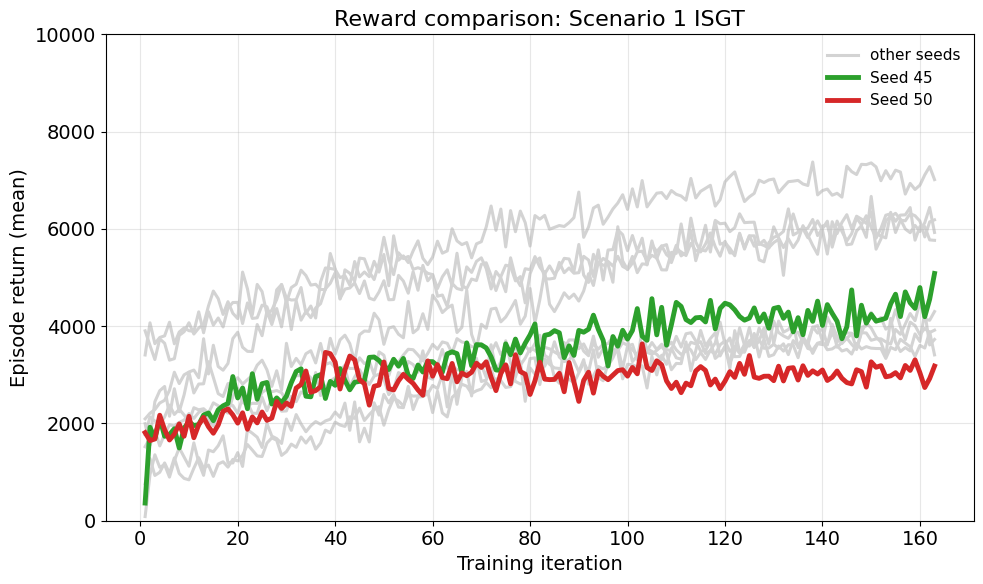

In [10]:
exp_name = 'scenario1_v2_ISGT'
seeds = np.arange(42,52,1)
paths = []
labels = []
for i, seed in enumerate(seeds):
    path = f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed{seed}_run{i+1}/PPO_energy_market_run/progress.csv'
    paths.append(path)
    labels.append(f'Seed {seed}')
# paths = [
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run1/PPO_energy_market_run/progress.csv',
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run2/PPO_energy_market_run/progress.csv',
#     # f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run3/PPO_energy_market_run/progress.csv'
# ]
fig, ax = plot_rewards_comparison_multiseed_ind(
    paths,
    labels=labels,
    title="Reward comparison: Scenario 1 ISGT",
    figsize=(10, 6),
    ylim=[0,10000]
)
plt.show()

fig, ax = plot_rewards_comparison_multiseed_ind(
    paths, seeds=seeds,
    title="Reward comparison: Scenario 1 ISGT",
    figsize=(10, 6), ylim=(0, 10000),
    highlight_seeds=[45, 50],
    highlight_colors=["tab:green", "tab:red"],
)
plt.show()


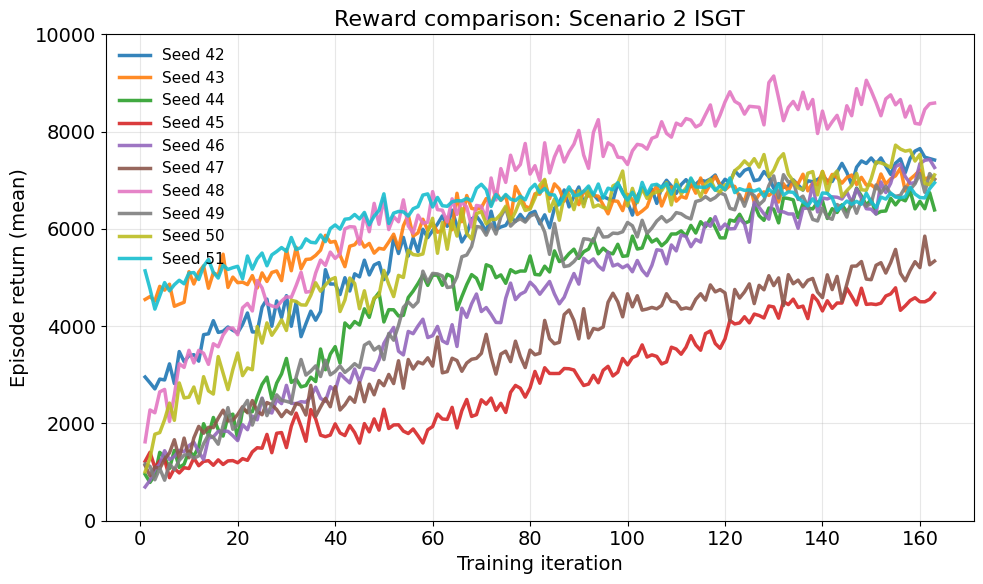

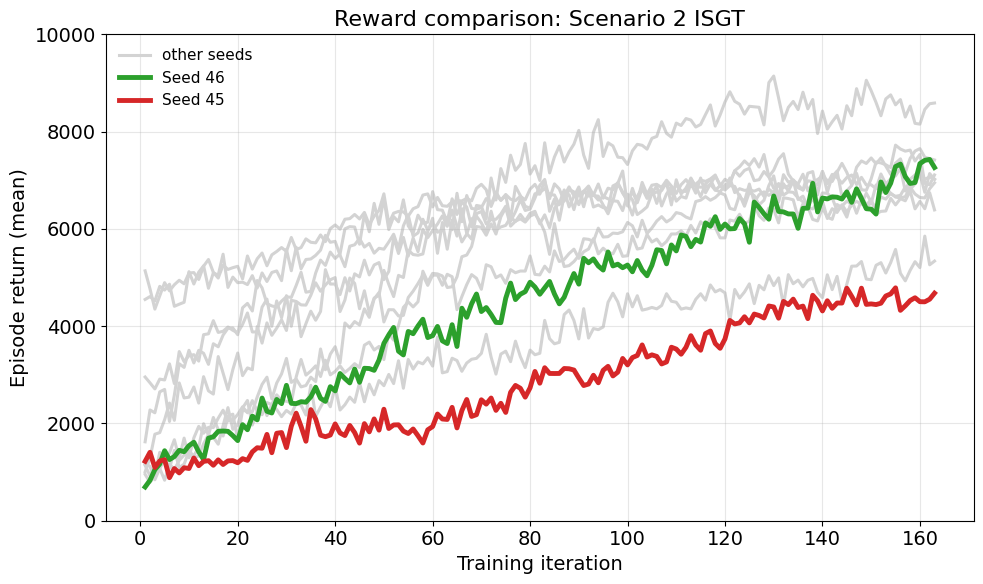

In [11]:
exp_name = 'scenario2_v2_ISGT'
seeds = np.arange(42,52,1)
paths = []
labels = []
for i, seed in enumerate(seeds):
    path = f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed{seed}_run{i+1}/PPO_energy_market_run/progress.csv'
    paths.append(path)
    labels.append(f'Seed {seed}')
# paths = [
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run1/PPO_energy_market_run/progress.csv',
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run2/PPO_energy_market_run/progress.csv',
#     # f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run3/PPO_energy_market_run/progress.csv'
# ]
fig, ax = plot_rewards_comparison_multiseed_ind(
    paths,
    labels=labels,
    title="Reward comparison: Scenario 2 ISGT",
    figsize=(10, 6),
    ylim=[0,10000]
)
plt.show()

fig, ax = plot_rewards_comparison_multiseed_ind(
    paths, seeds=seeds,
    title="Reward comparison: Scenario 2 ISGT",
    figsize=(10, 6), ylim=(0, 10000),
    highlight_seeds=[46, 45],
    highlight_colors=["tab:green", "tab:red"],
)
plt.show()

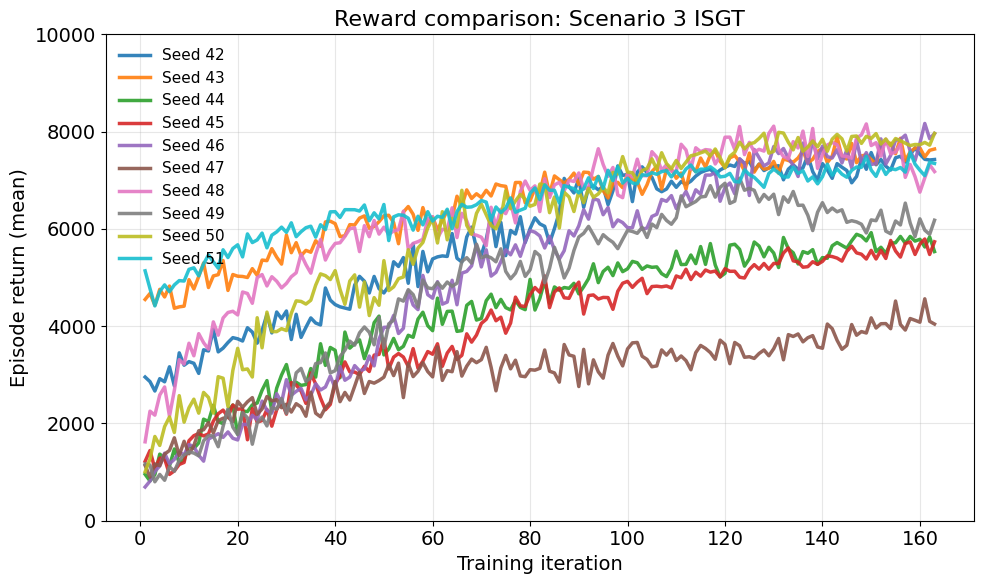

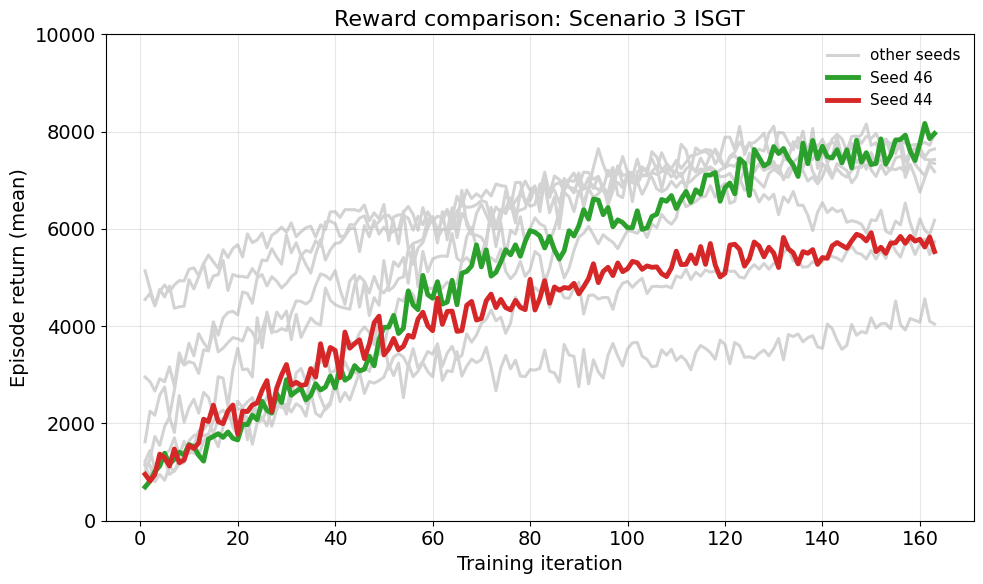

In [12]:
exp_name = 'scenario3_v2_ISGT'
seeds = np.arange(42,52,1)
paths = []
labels = []
for i, seed in enumerate(seeds):
    path = f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed{seed}_run{i+1}/PPO_energy_market_run/progress.csv'
    paths.append(path)
    labels.append(f'Seed {seed}')
# paths = [
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run1/PPO_energy_market_run/progress.csv',
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run2/PPO_energy_market_run/progress.csv',
#     # f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run3/PPO_energy_market_run/progress.csv'
# ]
fig, ax = plot_rewards_comparison_multiseed_ind(
    paths,
    labels=labels,
    title="Reward comparison: Scenario 3 ISGT",
    figsize=(10, 6),
    ylim=[0,10000]
)
plt.show()

fig, ax = plot_rewards_comparison_multiseed_ind(
    paths, seeds=seeds,
    title="Reward comparison: Scenario 3 ISGT",
    figsize=(10, 6), ylim=(0, 10000),
    highlight_seeds=[46, 44],
    highlight_colors=["tab:green", "tab:red"],
)
plt.show()

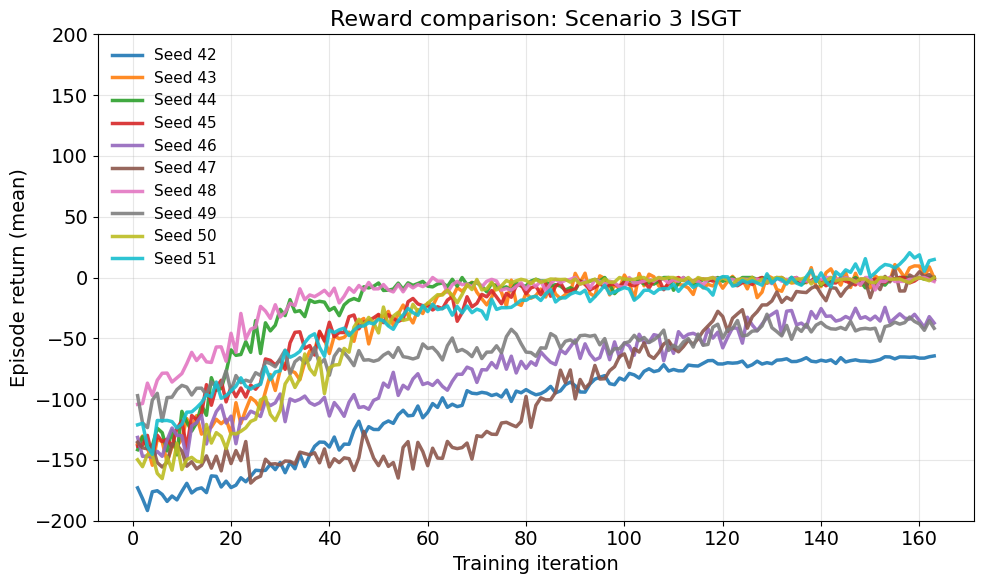

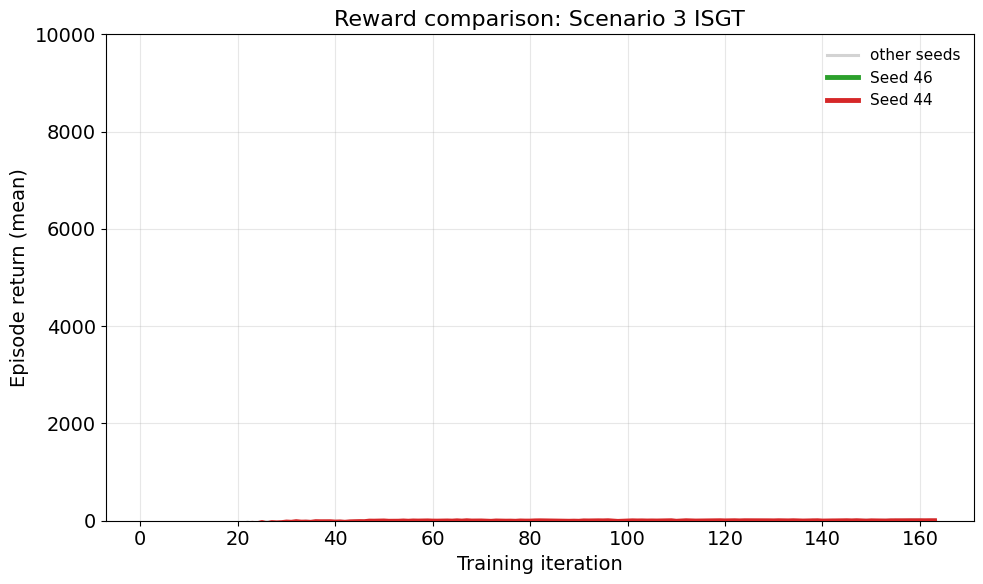

In [13]:
exp_name = 'desc_70p_30u_gini'
seeds = np.arange(42,52,1)
paths = []
labels = []
for i, seed in enumerate(seeds):
    path = f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed{seed}_run{i+1}/PPO_energy_market_run/progress.csv'
    paths.append(path)
    labels.append(f'Seed {seed}')
# paths = [
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run1/PPO_energy_market_run/progress.csv',
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run2/PPO_energy_market_run/progress.csv',
#     # f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run3/PPO_energy_market_run/progress.csv'
# ]
fig, ax = plot_rewards_comparison_multiseed_ind(
    paths,
    labels=labels,
    title="Reward comparison: Scenario 3 ISGT",
    figsize=(10, 6),
    ylim=[-200,200]
)
plt.show()

fig, ax = plot_rewards_comparison_multiseed_ind(
    paths, seeds=seeds,
    title="Reward comparison: Scenario 3 ISGT",
    figsize=(10, 6), ylim=(0, 10000),
    highlight_seeds=[46, 44],
    highlight_colors=["tab:green", "tab:red"],
)
plt.show()

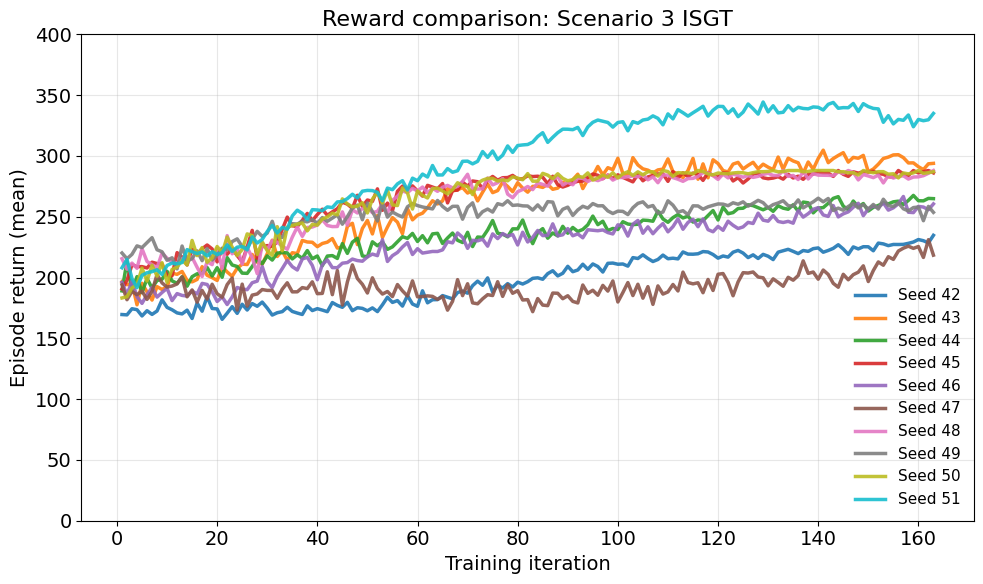

In [14]:
exp_name = 'desc_50p_50u_jain'
seeds = np.arange(42,52,1)
paths = []
labels = []
for i, seed in enumerate(seeds):
    path = f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed{seed}_run{i+1}/PPO_energy_market_run/progress.csv'
    paths.append(path)
    labels.append(f'Seed {seed}')
# paths = [
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run1/PPO_energy_market_run/progress.csv',
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run2/PPO_energy_market_run/progress.csv',
#     # f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run3/PPO_energy_market_run/progress.csv'
# ]
fig, ax = plot_rewards_comparison_multiseed_ind(
    paths,
    labels=labels,
    title="Reward comparison: Scenario 3 ISGT",
    figsize=(10, 6),
    ylim=[0,400]
)
plt.show()

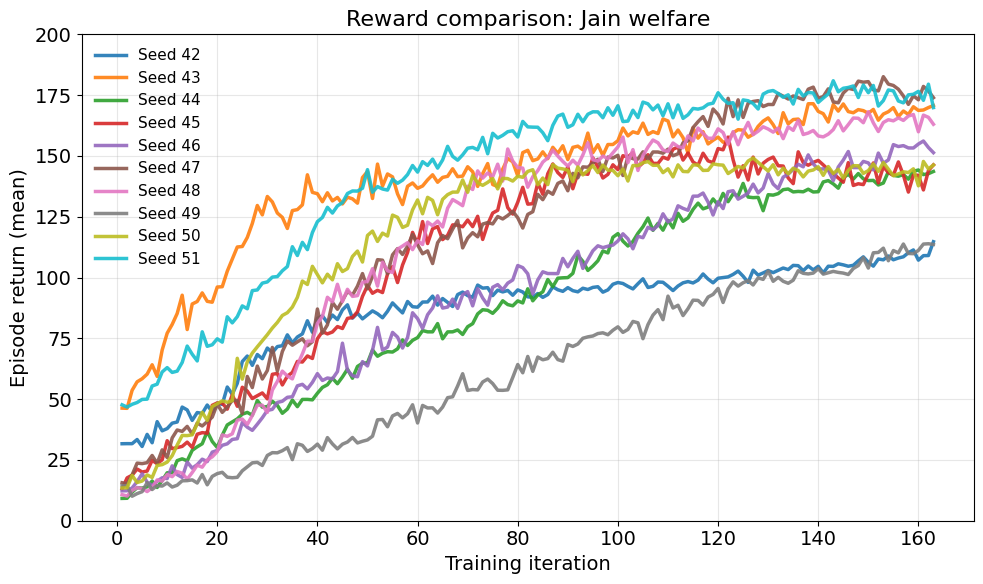

In [15]:
exp_name = 'desc_pu_jain'
seeds = np.arange(42,52,1)
paths = []
labels = []
for i, seed in enumerate(seeds):
    path = f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed{seed}_run{i+1}/PPO_energy_market_run/progress.csv'
    paths.append(path)
    labels.append(f'Seed {seed}')
# paths = [
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run1/PPO_energy_market_run/progress.csv',
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run2/PPO_energy_market_run/progress.csv',
#     # f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run3/PPO_energy_market_run/progress.csv'
# ]
fig, ax = plot_rewards_comparison_multiseed_ind(
    paths,
    labels=labels,
    title="Reward comparison: Jain welfare",
    figsize=(10, 6),
    ylim=[0,200]
)
plt.show()

{'Scenario 1 ISGT': ['/home/juanbmedina/rllib/exp_results_repro/desc_pu_jain/energy_market_training_seed42_run1/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/desc_pu_jain/energy_market_training_seed43_run2/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/desc_pu_jain/energy_market_training_seed44_run3/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/desc_pu_jain/energy_market_training_seed45_run4/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/desc_pu_jain/energy_market_training_seed46_run5/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/desc_pu_jain/energy_market_training_seed47_run6/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/desc_pu_jain/energy_market_training_seed48_run7/PPO_energy_market_run/progress.csv', '/home/juanbmedina/rllib/exp_results_repro/desc_pu_jain/energy_market_training_seed

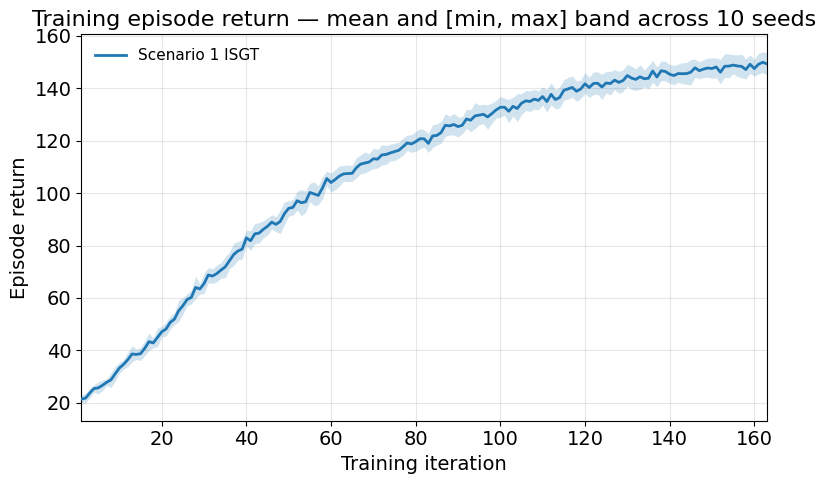

In [16]:
base_root = "/home/juanbmedina/rllib/exp_results_repro"
seeds = np.arange(42, 52)

def collect_paths(exp_name, seeds):
    return [
        f"{base_root}/{exp_name}/energy_market_training_seed{s}_run{i+1}"
        f"/PPO_energy_market_run/progress.csv"
        for i, s in enumerate(seeds)
    ]

experiments = {
    "Scenario 1 ISGT":  collect_paths("desc_pu_jain", seeds),
    # "Scenario 2 ISGT":     collect_paths("scenario2_v2_ISGT", seeds),
    # "Scenario 3 ISGT": collect_paths("scenario3_v2_ISGT", seeds),
    # "Scenario 4 Desc.": collect_paths("descentralized_exp", seeds),
}
print(experiments)

fig, ax = plot_rewards_comparison_multiseed(
    experiments,
    seed_aggregation="mean",     # o "envelope"
    figsize=(8, 5),
    title="Training episode return — mean and [min, max] band across 10 seeds",
)
plt.show()

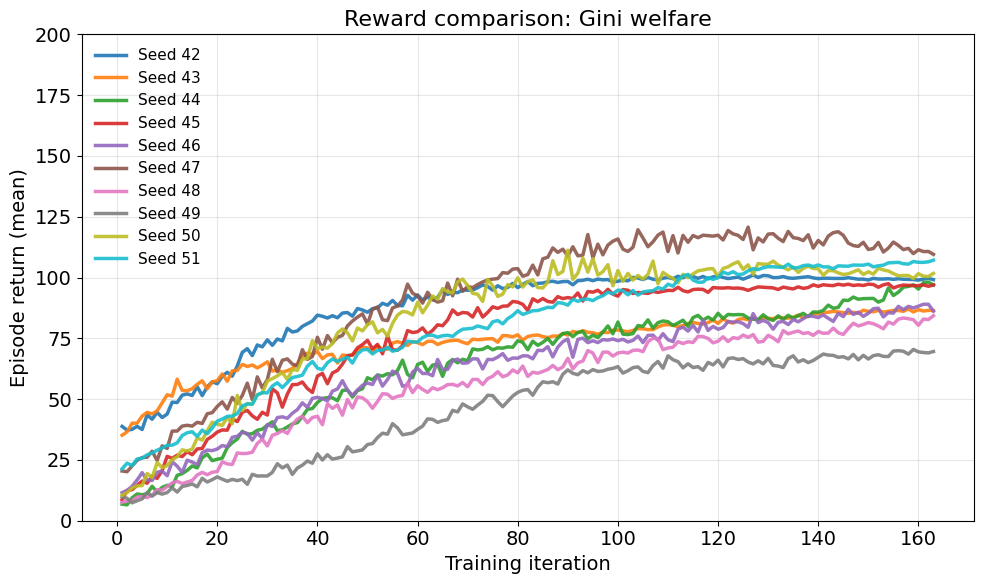

In [18]:
exp_name = 'desc_pu_gini'
seeds = np.arange(42,52,1)
paths = []
labels = []
for i, seed in enumerate(seeds):
    path = f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed{seed}_run{i+1}/PPO_energy_market_run/progress.csv'
    paths.append(path)
    labels.append(f'Seed {seed}')
# paths = [
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run1/PPO_energy_market_run/progress.csv',
#     f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run2/PPO_energy_market_run/progress.csv',
#     # f'/home/juanbmedina/rllib/exp_results_repro/{exp_name}/energy_market_training_seed42_run3/PPO_energy_market_run/progress.csv'
# ]
fig, ax = plot_rewards_comparison_multiseed_ind(
    paths,
    labels=labels,
    title="Reward comparison: Gini welfare",
    figsize=(10, 6),
    ylim=[0,200]
)
plt.show()